# LSTM Financial Forecasting for Stock Price Prediction

This project uses a stacked Long Short-Term Memory (LSTM) neural network to forecast stock closing prices from historical OHLCV (open, high, low, close, volume) market data.

## Overview

Time series forecasting in financial markets is challenging because prices reflect temporal dependencies, trend changes, and short-term noise. This notebook demonstrates an end-to-end deep learning workflow for sequence modeling using historical equity data.

In this project, I:

- Download historical stock data with `yfinance`
- Normalize and window the time series into supervised learning examples
- Build and train a stacked LSTM model in Keras
- Evaluate forecasting performance on a hold-out test set
- Visualize predicted versus actual closing prices
- Discuss model limitations, practical use cases, and next steps

## Objective

The goal is to show how recurrent neural networks can be applied to financial time series data to learn short-term temporal patterns and generate next-step price forecasts. This project is intended as a portfolio demonstration of sequence modeling, deep learning workflow design, and practical forecasting analysis in Python.


In [8]:
# If running in Google Colab, install yfinance (run once)
!pip install -q yfinance

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
# Configuration
TICKER = "AAPL"
START_DATE = "2019-01-01"
END_DATE = "2024-10-31"

# Download daily price data
data = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

# Keep OHLCV features for multivariate forecasting
print(data.head())
print("Data shape:", data.shape)

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.503727  37.724590  36.627404  36.784146  148158800
2019-01-03  33.768078  34.606402  33.722955  34.193175  365248800
2019-01-04  35.209606  35.278479  34.150423  34.323786  234428400
2019-01-07  35.131245  35.344984  34.649149  35.314110  219111200
2019-01-08  35.800957  36.055068  35.271365  35.518348  164101200
Data shape: (1468, 5)


In [11]:
# Use all original columns as features
values = data.values

# Train/test split by time (no shuffling)
train_size = int(len(values) * 0.8)
train_data = values[:train_size]
test_data = values[train_size:]

# Scale features to [0, 1] using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Window the time series into supervised learning pairs
def create_windowed_dataset(data_array, window_size, target_col_index):
    """Create (X, y) pairs from a multivariate time series.

    Parameters
    ----------
    data_array : np.ndarray
        Scaled time series of shape (num_timesteps, num_features).
    window_size : int
        Number of past days to include in each input sequence.
    target_col_index : int
        Index of the column to predict (e.g., Close price).

    Returns
    -------
    X : np.ndarray of shape (num_samples, window_size, num_features)
    y : np.ndarray of shape (num_samples, 1)
    """
    X, y = [], []
    for i in range(window_size, len(data_array)):
        X.append(data_array[i - window_size:i])
        y.append(data_array[i, target_col_index])
    return np.array(X), np.array(y).reshape(-1, 1)

WINDOW_SIZE = 60   # Tunable: number of historical days used as input
TARGET_COL_INDEX = data.columns.get_loc(('Close', TICKER))

X_train, y_train = create_windowed_dataset(train_scaled, WINDOW_SIZE, TARGET_COL_INDEX)
X_test, y_test = create_windowed_dataset(test_scaled, WINDOW_SIZE, TARGET_COL_INDEX)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1114, 60, 5)
y_train shape: (1114, 1)
X_test shape: (234, 60, 5)
y_test shape: (234, 1)


In [12]:
# Build a stacked LSTM model

NUM_UNITS_1 = 100
NUM_UNITS_2 = 50
DROPOUT_RATE = 0.2

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(NUM_UNITS_1, return_sequences=True),
    Dropout(DROPOUT_RATE),
    LSTM(NUM_UNITS_2),
    Dropout(DROPOUT_RATE),
    Dense(1),
])

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,651 (283.79 KB)

 Trainable params: 72,651 (283.79 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model with early stopping
EPOCHS = 30
BATCH_SIZE = 32

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=0,
)

print(f"Training completed in {len(history.history['loss'])} epochs.")

Training completed in 17 epochs.


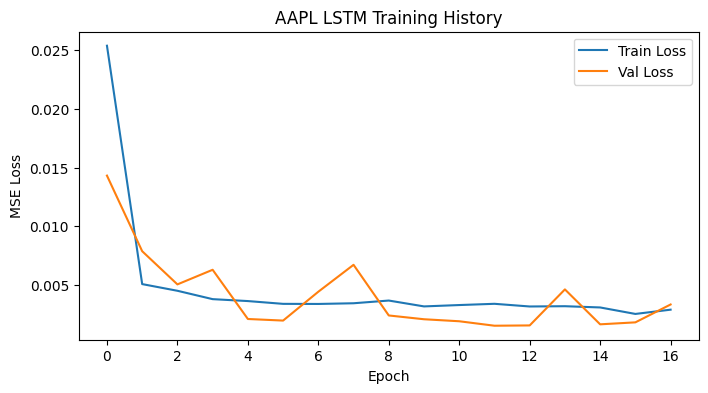

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
Test RMSE: 6.273491011905785


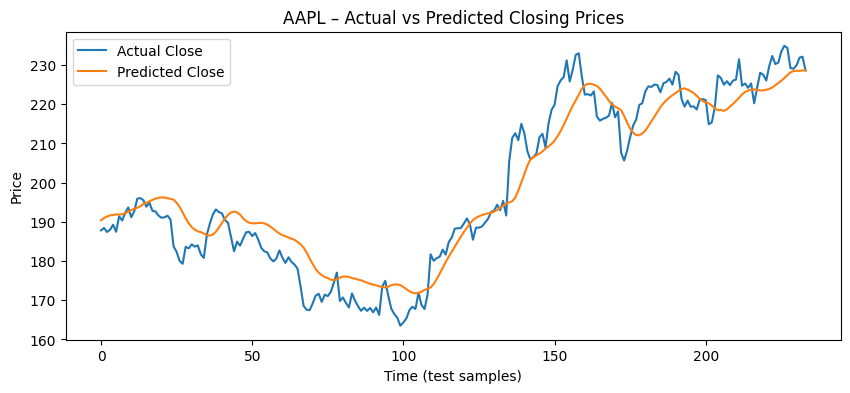

In [14]:
# Plot training and validation loss over epochs
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title(f"{TICKER} LSTM Training History")
plt.show()

# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Inverse-transform the predictions and true values
# Build arrays that match the scaler's expected shape
num_features = train_scaled.shape[1]

test_pred_full = np.zeros((len(y_pred_scaled), num_features))
test_true_full = np.zeros((len(y_test), num_features))

test_pred_full[:, TARGET_COL_INDEX] = y_pred_scaled[:, 0]
test_true_full[:, TARGET_COL_INDEX] = y_test[:, 0]

y_pred = scaler.inverse_transform(test_pred_full)[:, TARGET_COL_INDEX]
y_true = scaler.inverse_transform(test_true_full)[:, TARGET_COL_INDEX]

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Test RMSE:", rmse)

# Plot actual vs predicted prices
plt.figure(figsize=(10, 4))
plt.plot(y_true, label="Actual Close")
plt.plot(y_pred, label="Predicted Close")
plt.xlabel("Time (test samples)")
plt.ylabel("Price")
plt.title(f"{TICKER} – Actual vs Predicted Closing Prices")
plt.legend()
plt.show()

## Project Summary

This project applies a stacked LSTM network to forecast daily closing prices for Apple (AAPL) using historical OHLCV market data. The workflow includes data collection with `yfinance`, feature scaling, rolling-window sequence construction, model training with early stopping, inverse transformation of predictions, and hold-out evaluation.

The model demonstrates how recurrent neural networks can be used for financial time-series forecasting while preserving the sequential structure of the data. Although stock prediction remains noisy and uncertain, this project shows a complete deep learning forecasting pipeline and highlights practical skills in sequence modeling, preprocessing, evaluation, and visualization.

### Potential next steps
- Compare the LSTM against simpler baselines such as persistence, linear regression, or ARIMA
- Expand from one ticker to multiple assets or macroeconomic features
- Add walk-forward validation for a more realistic forecasting setup
- Optimize hyperparameters such as window size, network depth, and dropout rate